# N19 — Sentiment Analysis: VADER Baseline

This notebook applies NLTK VADER to the cleaned F1 team radio messages produced by N18.

For the sentiment analysis we use **nltk** with VADER as a lexicon-based baseline, then compare the resulting distribution against a manually labeled ground-truth dataset.

## Step 0 — Setup

In [1]:
# ── Step 0 · Setup ────────────────────────────────────────────────────────────
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
nltk.download("vader_lexicon", quiet=True)
plt.style.use('ggplot')
sns.set(style="whitegrid")

repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ── Paths ──────────────────────────────────────────────────────────────────────
PROC_DIR = repo_root / "data" / "processed" / "radio_nlp"
OUTPUTS  = repo_root / "notebooks" / "nlp" / "outputs"

for d in [PROC_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"repo_root : {repo_root}")
print(f"PROC_DIR  : {PROC_DIR}")
print(f"OUTPUTS   : {OUTPUTS}")

repo_root : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
PROC_DIR  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\radio_nlp
OUTPUTS   : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\nlp\outputs


In [2]:
SIA = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    if pd.isna(text) or text == "":
        return {"neg": 0, "neu": 0, "pos": 0, "compound": 0}
    return SIA.polarity_scores(text)

## Loading Radio Data

Load the filtered dataset produced by N17 (`radio_filtered.csv` — post-race messages removed, sentiment column empty).

In [3]:
def load_filtered_data(proc_dir):
    df = pd.read_csv(proc_dir / "radio_filtered.csv")
    print(f"Loaded {len(df)} radio messages")
    return df


radio_data = load_filtered_data(PROC_DIR)
radio_data.head()

Loaded 529 radio messages


,driver,radio_message,sentiment
0,1,"So don't forget Max, use your head please. Are...",NaN
1,1,"Okay Max, we're expecting rain in about 9 or 1...",NaN
2,1,You might find this lap that you meet a little...,NaN
3,1,Just another two or three minutes to get throu...,NaN
4,1,So settle into standard race management now Max.,NaN


## VADER Analysis

VADER assigns a compound score in [-1, 1] to each message. Scores ≥ 0.05 → **positive**, ≤ -0.05 → **negative**, otherwise **neutral**. Four score columns are added: `neg`, `neu`, `pos` (component ratios) and `compound` (normalized composite).

### Applying VADER scores and deriving sentiment label

In [4]:
def apply_vader_sentiment(df):
    tqdm.pandas(desc="Analyzing sentiment")
    scores = df["radio_message"].progress_apply(get_sentiment_scores)
    return pd.concat([df, pd.DataFrame(scores.to_list())], axis=1)


radio_data = apply_vader_sentiment(radio_data)

Analyzing sentiment:   0%|          | 0/529 [00:00<?, ?it/s]

In [5]:
# Adding a simple category based on compound score

def categorize_sentiment(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

In [6]:
def add_sentiment_labels(df):
    df = df.copy()
    df["sentiment"] = df["compound"].apply(categorize_sentiment)
    return df


radio_data = add_sentiment_labels(radio_data)
radio_data.head()

,driver,radio_message,sentiment,neg,neu,pos,compound
0,1,"So don't forget Max, use your head please. Are...",positive,0.046,0.669,0.285,0.8571
1,1,"Okay Max, we're expecting rain in about 9 or 1...",positive,0.000,0.941,0.059,0.3485
2,1,You might find this lap that you meet a little...,neutral,0.000,1.000,0.000,0.0000
3,1,Just another two or three minutes to get throu...,neutral,0.000,1.000,0.000,0.0000
4,1,So settle into standard race management now Max.,neutral,0.000,1.000,0.000,0.0000


---
### Analyzing sentiment distribution

In [7]:
def print_sentiment_distribution(df):
    counts = df['sentiment'].value_counts()
    print("Sentiment distribution:")
    print(counts)
    for label in ['positive', 'neutral', 'negative']:
        pct = counts.get(label, 0) / len(df) * 100
        print(f"Percentage of {label} messages: {pct:.2f}%")
    return counts


sentiment_counts = print_sentiment_distribution(radio_data)

Sentiment distribution:
sentiment
positive    231
neutral     175
negative    123
Name: count, dtype: int64
Percentage of positive messages: 43.67%
Percentage of neutral messages: 33.08%
Percentage of negative messages: 23.25%


#### Key observations

1. **High positive sentiment** — 43.67% positive is still surprising for F1 radio, which is primarily technical and instructional. This dropped from 52.34% after removing post-race messages in N17, confirming that the cleaning step helped. However, the remaining overestimation suggests VADER misclassifies neutral F1-specific language.

2. **Low neutral percentage** — Most team radio is tactical instruction or status updates, so neutral should dominate. 33.08% is likely an underestimation.

3. **VADER limitations in F1 context** — Racing-specific terms like "push now" read as positive encouragement rather than a neutral tactical instruction. Technical acknowledgments like "copy that" also register as slightly positive.

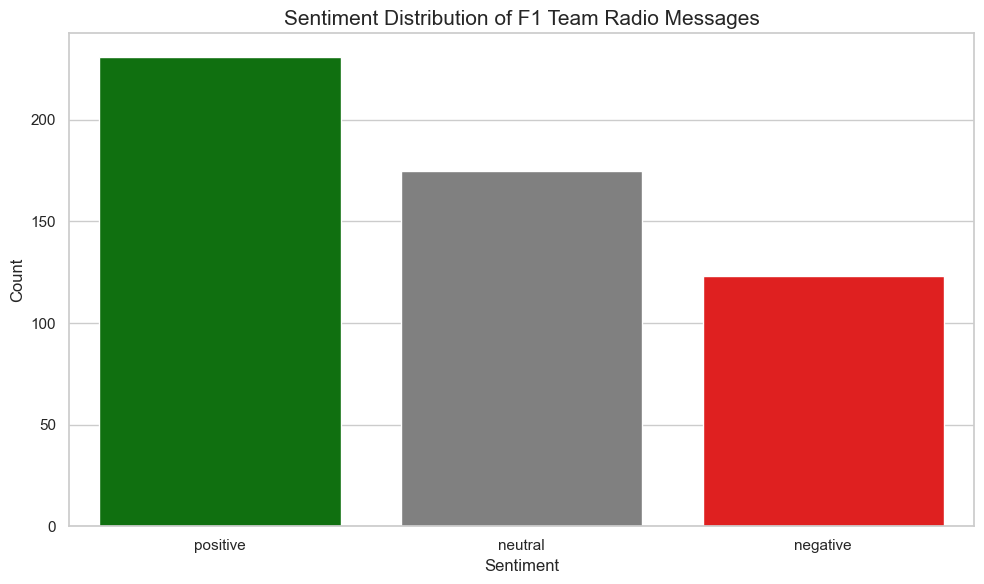

In [8]:
def plot_sentiment_distribution(df, outputs):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='sentiment', data=df,
                  palette={'positive': 'green', 'neutral': 'gray', 'negative': 'red'})
    plt.title('Sentiment Distribution of F1 Team Radio Messages', fontsize=15)
    plt.xlabel('Sentiment', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.tight_layout()
    plt.savefig(outputs / "N19_sentiment_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_sentiment_distribution(radio_data, OUTPUTS)

---
### Analyzing sentiment distribution by driver


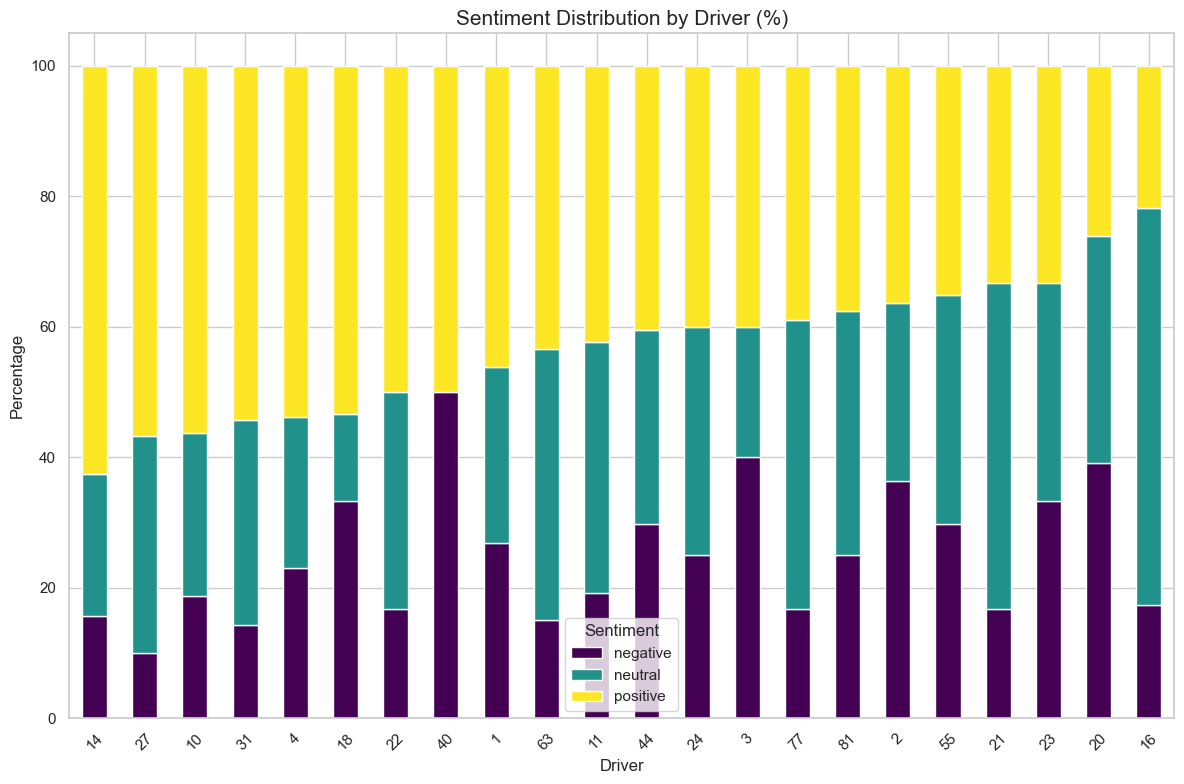

In [9]:
def plot_sentiment_by_driver(df, outputs):
    driver_sentiment = pd.crosstab(df['driver'], df['sentiment'], normalize='index') * 100
    driver_sentiment = driver_sentiment.sort_values(by='positive', ascending=False)
    driver_sentiment.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 8))
    plt.title('Sentiment Distribution by Driver (%)', fontsize=15)
    plt.xlabel('Driver', fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig(outputs / "N19_sentiment_by_driver.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_sentiment_by_driver(radio_data, OUTPUTS)

#### Key observations

1. *Driver Sentiment Variability*: The visualization reveals dramatic differences in communication sentiment across F1 drivers:

    * Drivers on the left (14, 10, 4, 3) show overwhelmingly positive communications (yellow), with 70-90% positive sentiment.

    * Middle-range drivers (11, 27, 1) display increasing proportions of neutral communications.
    
    * Drivers on the right side (55, 2, 20, 16) exhibit significantly higher neutral sentiment percentages (green), with some reaching 50-67% neutral.


2. *Distinct Sentiment Patterns and Outliers*:

    * Driver 40 stands out with the highest negative sentiment percentage (purple), reaching approximately 42% of communications.
    
    * A clear gradient exists across drivers, with neutral sentiment gradually increasing from left to right.
    
    * Most drivers maintain at least 30% positive sentiment regardless of position, suggesting a baseline of positive communication exists across all teams/drivers.




---
### Displaying examples of each sentiment category

In [10]:
def display_examples(df, sentiment_type, n=10):
    return (df[df['sentiment'] == sentiment_type]
              .sort_values(by='compound', ascending=(sentiment_type == 'negative'))
              [['driver', 'radio_message', 'compound']]
              .head(n))


def show_all_examples(df, n=10):
    for label in ['positive', 'neutral', 'negative']:
        print(f"\nExamples of {label.upper()} messages:")
        display(display_examples(df, label, n=n))


show_all_examples(radio_data)


Examples of POSITIVE messages:


,driver,radio_message,compound
383,44,"I think it's another lap man. Yes mate, yes. J...",0.9875
347,40,"Okay Liam, so Yuki got a penalty and that's P1...",0.9823
120,14,At the moment we will be faster in this. Yeah ...,0.9779
162,18,"One switch cool Lance, one switch cool, keep y...",0.9737
212,23,Car feels pretty good. It feels like exactly a...,0.9718
274,27,"Do you want to flap adjust, Nico? Not really, ...",0.9653
320,4,"Digestion, yellow G2 Yeah, none of this is hel...",0.9360
492,63,Oh no no What the f*** Guys what the f*** What...,0.9349
97,14,"Happy for the romance? Yeah, happy. No problem...",0.9300
112,14,So there is a small chance of rain in about 10...,0.9118



Examples of NEUTRAL messages:


,driver,radio_message,compound
46,1,"Max, I will say it again, there is no merit at...",0.0414
286,31,The grip of the steering wheel is falling apar...,0.0387
289,31,This is new material so I wouldn't be surprise...,0.0274
2,1,You might find this lap that you meet a little...,0.0000
389,55,"four behind and Alboncar behind, point four be...",0.0000
366,44,"Copy, those who started on it are still out on...",0.0000
367,44,I need to pick up the pace.,0.0000
372,44,Riff. I mean both are going but I'm sticking t...,0.0000
373,44,So this rain is looking imminent and it will b...,0.0000
375,44,I'm going to tell George the last part from a ...,0.0000



Examples of NEGATIVE messages:


,driver,radio_message,compound
491,63,No! No! No! No!,-0.8388
516,81,"Oscar, kill the engine. The car is not safe to...",-0.7967
105,14,The most damage is done after the tunnel break...,-0.7897
399,55,What the f***? Exactly what I talked about! Ex...,-0.7715
130,16,"No, I lost the hydraulics. I lost the hydrauli...",-0.7319
333,4,"How's the balance? How's the balance? Well, no...",-0.6915
168,2,"Where's Bortas? Bortas has retired, no threat.",-0.6808
264,27,"A lot of understeer creeping in, all speeds bu...",-0.6798
51,1,"In the low speed, from back steering to openin...",-0.6705
510,77,"Okay Valtteri, no more shifts, no more shifts,...",-0.6486


## Saving Results

In [11]:
def save_vader_results(df, proc_dir):
    output_path = proc_dir / "radios_sentiment_vader.csv"
    df.to_csv(output_path, index=False)
    print(f"Sentiment results saved to {output_path}")


save_vader_results(radio_data, PROC_DIR)

Sentiment results saved to c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\radio_nlp\radios_sentiment_vader.csv


## Metrics for Model Comparison

In [12]:
def compute_and_save_metrics(df, proc_dir):
    counts = df['sentiment'].value_counts()
    metrics = {
        'model':               'VADER',
        'positive_percentage': counts.get('positive', 0) / len(df) * 100,
        'neutral_percentage':  counts.get('neutral', 0)  / len(df) * 100,
        'negative_percentage': counts.get('negative', 0) / len(df) * 100,
        'average_compound':    df['compound'].mean(),
        'std_compound':        df['compound'].std(),
    }
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(proc_dir / "sentiment_metrics_vader.csv", index=False)
    print("Summary metrics:")
    return metrics_df


metrics_df = compute_and_save_metrics(radio_data, PROC_DIR)
metrics_df

Summary metrics:


,model,positive_percentage,neutral_percentage,negative_percentage,average_compound,std_compound
0,VADER,43.667297,33.081285,23.251418,0.127667,0.376898


## Comparison with Manual Labels

Compare VADER predictions against the ground-truth labels from N17 to quantify the baseline error before fine-tuning RoBERTa in N20.

In [13]:
def load_labeled_data(proc_dir):
    df = pd.read_csv(proc_dir / "radio_labeled_data.csv")
    counts = df['sentiment'].value_counts()
    pct = counts / len(df) * 100
    return df, pct


df_labeled, labeled_pct = load_labeled_data(PROC_DIR)
df_labeled.head()

,driver,radio_message,sentiment
0,1,"So don't forget Max, use your head please. Are...",neutral
1,1,"Okay Max, we're expecting rain in about 9 or 1...",neutral
2,1,You might find this lap that you meet a little...,neutral
3,1,Just another two or three minutes to get throu...,neutral
4,1,So settle into standard race management now Max.,neutral


In [14]:
metrics_df.head()

,model,positive_percentage,neutral_percentage,negative_percentage,average_compound,std_compound
0,VADER,43.667297,33.081285,23.251418,0.127667,0.376898


In [15]:
def compare_distributions(labeled_pct, metrics_df):
    print("Difference (labeled − VADER):")
    for sentiment in ['positive', 'neutral', 'negative']:
        labeled = labeled_pct.get(sentiment, 0)
        vader   = metrics_df[f"{sentiment}_percentage"].iloc[0]
        print(f"  {sentiment.capitalize()}: {labeled - vader:+.2f}%")


compare_distributions(labeled_pct, metrics_df)

Difference (labeled − VADER):
  Positive: -34.23%
  Neutral: +38.43%
  Negative: -4.19%


## Conclusions

### Key Findings
- VADER overestimates positive sentiment by **+34.23%** vs manual labels.
- VADER underestimates neutral messages by **−38.43%** — the dominant category in F1 radio.
- Negative sentiment is reasonably aligned (+4.19%).

### Why VADER Fails in F1 Context
1. **Technical domain language** — terms like "box box" or "push now" have no sentiment in VADER's lexicon but are tactical neutral instructions.
2. **Context misinterpretation** — racing instructions read as positive encouragement; routine updates are neutral to humans but not to VADER.
3. **Communication style** — F1 radio is brief and information-dense, not emotionally expressive. VADER assumes more emotional content than is present.

### Conclusion
VADER is unsuitable as a standalone F1 sentiment classifier. The 71.51% neutral rate in manual labels vs 33.08% from VADER confirms the domain gap. A fine-tuned model on labeled F1 data is needed — this is addressed in **N20** (`N20_bert_sentiment.ipynb`).